> **EXTRA — Approfondimento**: questa sezione costruisce le feature SSVI
> specifiche del progetto (max_cond1, shape_cond1, skew_stress, ...).
> Va oltre i requisiti base del corso di econometria.

# S&P 500 — SSVI Forecasting Dataset

**Goal**: construct a clean, look-ahead-free daily panel that can be used
to forecast *future realized volatility* from SSVI surface parameters and
market variables.

This notebook only builds and validates the dataset.
Predictive models are in `04_ssvi_forecasting_models.ipynb`.

**Inputs**
- `output/ssvi_all_dates_clean_results.csv` — calibrated SSVI parameters
- `output/no_arbitrage_clean_results.csv`   — no-arbitrage diagnostics
- `output/options_with_forward_iv_clean.csv` — spot prices and implied vols

**Output**: `output/ssvi_forecasting_dataset.csv`

## A. Imports and setup

In [1]:
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

BASE     = r"C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO"
NB_DIR   = os.path.join(BASE, "Notebook_newdata")
OUTPUT   = os.path.join(NB_DIR, 'output')
PLOT_DIR = os.path.join(OUTPUT, 'plots')
os.makedirs(OUTPUT,   exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Paths
SSVI_PATH    = os.path.join(OUTPUT, 'ssvi_all_dates_clean_results.csv')
NA_PATH      = os.path.join(OUTPUT, 'no_arbitrage_clean_results.csv')
OPTIONS_PATH = os.path.join(OUTPUT, 'options_with_forward_iv_clean.csv')
OUT_PATH     = os.path.join(OUTPUT, 'ssvi_forecasting_dataset.csv')

for p in [SSVI_PATH, NA_PATH, OPTIONS_PATH]:
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  {os.path.basename(p):45s} {status}')


  ssvi_all_dates_clean_results.csv              OK
  no_arbitrage_clean_results.csv                OK
  options_with_forward_iv_clean.csv             OK


## B. Load and merge inputs

In [2]:
# SSVI calibration results
df_ssvi = pd.read_csv(SSVI_PATH)
df_ssvi = df_ssvi[df_ssvi['success']].copy()
df_ssvi = df_ssvi.rename(columns={'time_elapsed': 'time_elapsed'})
print(f'SSVI results:    {len(df_ssvi):>5,} successful dates')

# No-arbitrage diagnostics
df_na = pd.read_csv(NA_PATH)
print(f'No-arb results:  {len(df_na):>5,} dates')

# Options dataset — extract daily spot price
df_opt = pd.read_csv(OPTIONS_PATH, usecols=['Time Elapsed', 'sp500'])
spot_daily = (
    df_opt
    .groupby('Time Elapsed')['sp500']
    .first()
    .rename_axis('time_elapsed')
    .sort_index()
    .reset_index()
)
print(f'Spot daily:      {len(spot_daily):>5,} dates')

# Merge on time_elapsed
daily = (
    spot_daily
    .merge(df_ssvi[['time_elapsed','alpha','beta','rho','eta','gamma',
                     'rmse_iv','n_obs']], on='time_elapsed', how='inner')
    .merge(df_na[['time_elapsed','max_cond1','max_cond2',
                   'butterfly_ok','calendar_ok','no_arbitrage']], on='time_elapsed', how='left')
    .sort_values('time_elapsed')
    .reset_index(drop=True)
)

print(f'\nMerged daily:    {len(daily):>5,} rows  x  {len(daily.columns)} columns')
print(f'Date range:      {daily["time_elapsed"].min():.0f} – {daily["time_elapsed"].max():.0f}')
daily.head(3)

SSVI results:    2,666 successful dates
No-arb results:  2,666 dates


Spot daily:      2,768 dates

Merged daily:    2,666 rows  x  14 columns
Date range:      100 – 4014


,time_elapsed,sp500,alpha,beta,rho,eta,gamma,rmse_iv,n_obs,max_cond1,max_cond2,butterfly_ok,calendar_ok,no_arbitrage
0,100,1193.00,-3.252043,1.197822,-0.696203,1.066815,0.402919,0.000611,104,0.375238,1.157361,True,True,True
1,101,1194.95,-3.227598,1.165159,-0.703824,1.127754,0.377242,0.001086,126,0.527548,1.301775,True,True,True
2,102,1176.15,-3.155921,1.150344,-0.694766,1.127478,0.378601,0.000797,116,0.544678,1.319315,True,True,True


## C. Market features

All features are computed on the **past** — no look-ahead.

In [3]:
sp = daily['sp500']

# Log returns
daily['log_return']     = np.log(sp / sp.shift(1))
daily['abs_return']     = daily['log_return'].abs()
daily['squared_return'] = daily['log_return'] ** 2

# Backward-looking realized volatility (annualised)
def rv_backward(sq_ret, window):
    return np.sqrt(252 * sq_ret.rolling(window, min_periods=window).mean())

daily['RV5']  = rv_backward(daily['squared_return'], 5)
daily['RV10'] = rv_backward(daily['squared_return'], 10)
daily['RV20'] = rv_backward(daily['squared_return'], 20)

# Momentum / return features
daily['ret_5d']  = np.log(sp / sp.shift(5))
daily['ret_20d'] = np.log(sp / sp.shift(20))

print('Market features computed.')
daily[['log_return','RV5','RV10','RV20','ret_5d','ret_20d']].describe().round(4)

Market features computed.


,log_return,RV5,RV10,RV20,ret_5d,ret_20d
count,2665.0000,2661.0000,2656.0000,2646.0000,2661.0000,2646.0000
mean,0.0004,0.1354,0.1402,0.1444,0.0021,0.0086
std,0.0110,0.1101,0.1041,0.0982,0.0229,0.0443
min,-0.1108,0.0133,0.0151,0.0294,-0.2029,-0.3804
25%,-0.0035,0.0693,0.0775,0.0852,-0.0068,-0.0084
50%,0.0007,0.1082,0.1110,0.1183,0.0040,0.0148
75%,0.0054,0.1682,0.1740,0.1752,0.0142,0.0328
max,0.0911,1.3249,1.0786,0.8917,0.1618,0.2049


## D. SSVI-derived features

In [4]:
# Derived interaction features
daily['abs_rho']              = daily['rho'].abs()
daily['eta_gamma_interaction'] = daily['eta'] * daily['gamma']
daily['skew_stress']          = daily['abs_rho'] * daily['eta']
daily['cond2_stress']         = daily['max_cond2'].fillna(0.0)

print('SSVI-derived features:')
for col in ['abs_rho','eta_gamma_interaction','skew_stress','cond2_stress']:
    s = daily[col]
    print(f'  {col:28s}  mean={s.mean():.3f}  std={s.std():.3f}  max={s.max():.3f}')

SSVI-derived features:
  abs_rho                       mean=0.758  std=0.058  max=0.950
  eta_gamma_interaction         mean=0.404  std=0.042  max=0.546
  skew_stress                   mean=0.603  std=0.152  max=1.144
  cond2_stress                  mean=1.868  std=0.680  max=4.000


## E. Lag features

Lags of 1, 2, and 5 days for SSVI parameters and key market variables.
These capture autocorrelation and slow-moving regimes without introducing look-ahead.

In [5]:
LAG_COLS = ['alpha','beta','rho','eta','gamma','rmse_iv',
             'max_cond2','log_return','RV5','RV20']
LAGS     = [1, 2, 5]

for col in LAG_COLS:
    for lag in LAGS:
        daily[f'{col}_lag{lag}'] = daily[col].shift(lag)

lag_cols_created = [f'{c}_lag{l}' for c in LAG_COLS for l in LAGS]
print(f'Lag features created: {len(lag_cols_created)}')
print('Examples:', lag_cols_created[:6])

Lag features created: 30
Examples: ['alpha_lag1', 'alpha_lag2', 'alpha_lag5', 'beta_lag1', 'beta_lag2', 'beta_lag5']


## F. Future realized volatility targets

The targets are **forward-looking** by construction — they use returns *after* day $t$.
This is correct for a supervised forecasting task: features are known at time $t$,
targets are what we want to predict.

In [6]:
def rv_forward(sq_ret, horizon):
    """Annualised RV over the next `horizon` days (shift -horizon so target aligns with today)."""
    return np.sqrt(252 * sq_ret.shift(-horizon).rolling(horizon, min_periods=horizon).mean())

daily['RV5_future']  = rv_forward(daily['squared_return'], 5)
daily['RV20_future'] = rv_forward(daily['squared_return'], 20)

# Canonical target names
daily['target_RV5']  = daily['RV5_future']
daily['target_RV20'] = daily['RV20_future']

print('Forward targets:')
for col in ['target_RV5', 'target_RV20']:
    s = daily[col].dropna()
    print(f'  {col:15s}  n={len(s):,}  mean={s.mean():.4f}  std={s.std():.4f}  '
          f'min={s.min():.4f}  max={s.max():.4f}')

Forward targets:
  target_RV5       n=2,657  mean=0.1354  std=0.1101  min=0.0133  max=1.3249
  target_RV20      n=2,627  mean=0.1438  std=0.0983  min=0.0294  max=0.8917


## G. Train / test split (temporal)

In [7]:
TRAIN_FRAC = 0.80

n_total = len(daily)
n_train = int(n_total * TRAIN_FRAC)

daily['sample'] = 'test'
daily.loc[daily.index < n_train, 'sample'] = 'train'

train = daily[daily['sample'] == 'train']
test  = daily[daily['sample'] == 'test']

print(f'Total dates : {n_total}')
print(f'Train (80%) : {len(train):>5}  '
      f'[{train["time_elapsed"].min():.0f}, {train["time_elapsed"].max():.0f}]')
print(f'Test  (20%) : {len(test):>5}  '
      f'[{test["time_elapsed"].min():.0f}, {test["time_elapsed"].max():.0f}]')

Total dates : 2666
Train (80%) :  2132  [100, 3237]
Test  (20%) :   534  [3238, 4014]


## H. Clean final dataset

Drop rows with NaN generated by rolling windows, lags, and forward targets.
These are always at the edges of the series and not usable for modelling.

In [8]:
n_before = len(daily)

# Feature columns used in modelling (should have no NaN after drop)
FEATURE_COLS = [
    'alpha','beta','rho','eta','gamma','rmse_iv','n_obs',
    'abs_rho','eta_gamma_interaction','skew_stress','cond2_stress',
    'max_cond1','max_cond2',
    'log_return','abs_return','RV5','RV10','RV20','ret_5d','ret_20d',
] + lag_cols_created

TARGET_COLS = ['target_RV5', 'target_RV20']

# Drop rows where any feature or either target is NaN
drop_cols = FEATURE_COLS + TARGET_COLS
daily_clean = daily.dropna(subset=drop_cols).reset_index(drop=True)

n_after = len(daily_clean)
print(f'Rows before drop: {n_before}')
print(f'Rows after  drop: {n_after}  ({n_before-n_after} removed by rolling/lag/forward NaN)')

# Re-apply split labels after drop (split boundaries may shift slightly)
n_train = int(len(daily_clean) * TRAIN_FRAC)
daily_clean['sample'] = 'test'
daily_clean.loc[daily_clean.index < n_train, 'sample'] = 'train'

train_c = daily_clean[daily_clean['sample'] == 'train']
test_c  = daily_clean[daily_clean['sample'] == 'test']
print(f'\nFinal train: {len(train_c)}   test: {len(test_c)}')

Rows before drop: 2666
Rows after  drop: 2621  (45 removed by rolling/lag/forward NaN)



Final train: 2096   test: 525


In [9]:
# Save
daily_clean.to_csv(OUT_PATH, index=False)
print(f'Saved: {OUT_PATH}')
print(f'Shape: {daily_clean.shape}')

# Missing values check
n_miss = daily_clean[FEATURE_COLS + TARGET_COLS].isna().sum()
if n_miss.sum() == 0:
    print('No missing values in features or targets.')
else:
    print('Missing values:')
    print(n_miss[n_miss > 0])

Saved: C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO\Notebook_newdata\output\ssvi_forecasting_dataset.csv


Shape: (2621, 61)
No missing values in features or targets.


In [10]:
# Target distributions
print('Target summary:')
print(daily_clean[TARGET_COLS].describe().round(4).to_string())

# Top correlations with targets
base_features = ['alpha','beta','rho','eta','gamma','rmse_iv',
                  'abs_rho','skew_stress','cond2_stress',
                  'RV5','RV20','log_return','ret_5d','ret_20d']
corr = daily_clean[base_features + TARGET_COLS].corr()

print('\nTop correlations with target_RV5:')
print(corr['target_RV5'][base_features].abs().sort_values(ascending=False).head(8).round(3).to_string())

print('\nTop correlations with target_RV20:')
print(corr['target_RV20'][base_features].abs().sort_values(ascending=False).head(8).round(3).to_string())

Target summary:
       target_RV5  target_RV20
count   2621.0000    2621.0000
mean       0.1350       0.1437
std        0.1104       0.0984
min        0.0133       0.0294
25%        0.0690       0.0850
50%        0.1078       0.1176
75%        0.1676       0.1727
max        1.3249       0.8917

Top correlations with target_RV5:
RV5        0.665
beta       0.629
RV20       0.605
alpha      0.524
ret_20d    0.506
ret_5d     0.359
rho        0.325
abs_rho    0.325

Top correlations with target_RV20:
RV5        0.564
beta       0.548
RV20       0.511
alpha      0.438
ret_20d    0.353
ret_5d     0.286
rho        0.282
abs_rho    0.282


## I. Exploratory analysis

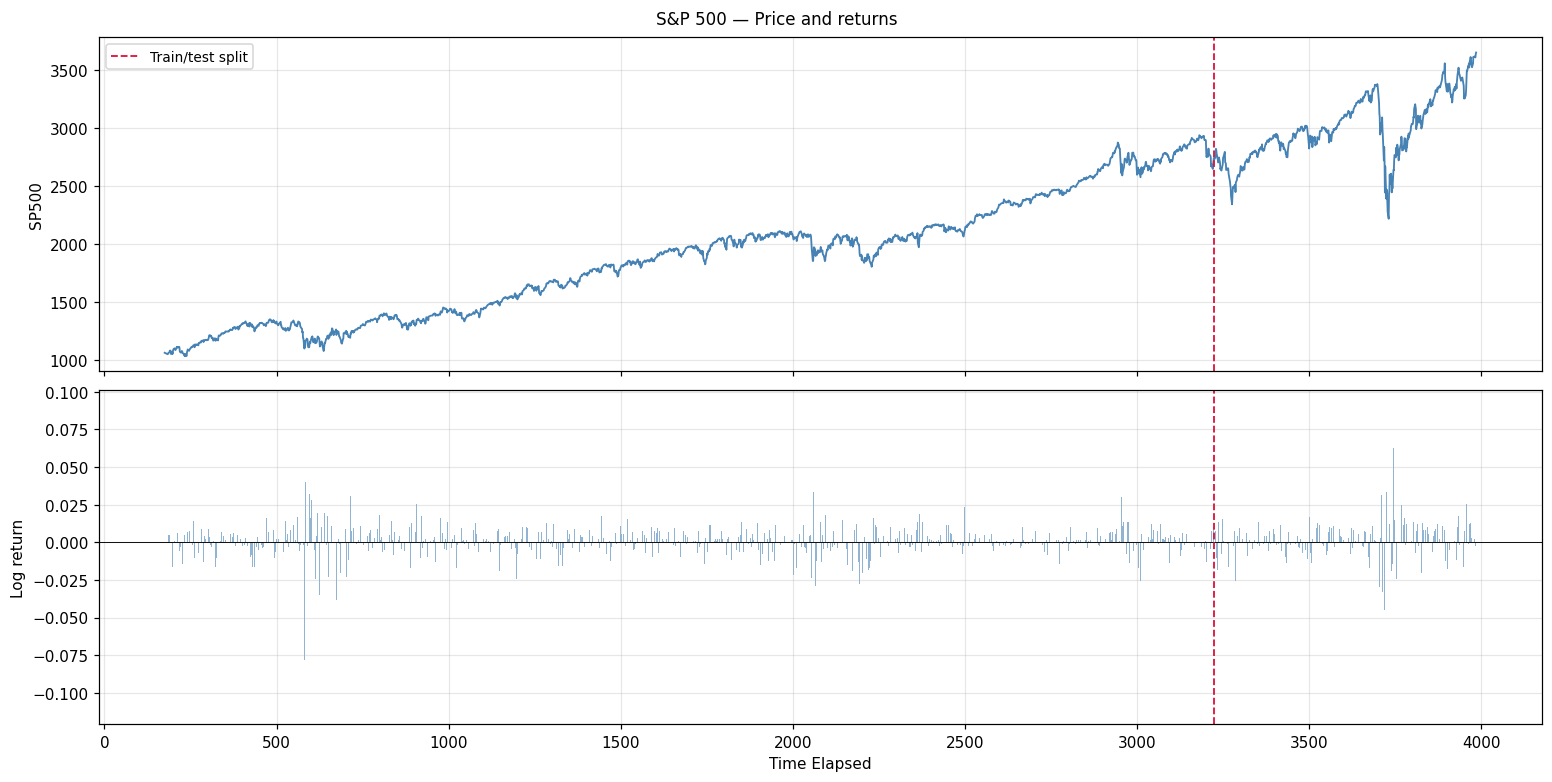

In [11]:
# SP500 returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)
fig.suptitle('S&P 500 — Price and returns', fontsize=11)

te = daily_clean['time_elapsed']

axes[0].plot(te, daily_clean['sp500'], lw=1.2, color='steelblue')
axes[0].set_ylabel('SP500')
axes[0].axvline(daily_clean.loc[daily_clean['sample']=='test','time_elapsed'].min(),
                color='crimson', lw=1.2, ls='--', label='Train/test split')
axes[0].legend(fontsize=9)

axes[1].bar(te, daily_clean['log_return'], width=0.8, color='steelblue', alpha=0.6)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].axvline(daily_clean.loc[daily_clean['sample']=='test','time_elapsed'].min(),
                color='crimson', lw=1.2, ls='--')
axes[1].set_ylabel('Log return')
axes[1].set_xlabel('Time Elapsed')

plt.show()

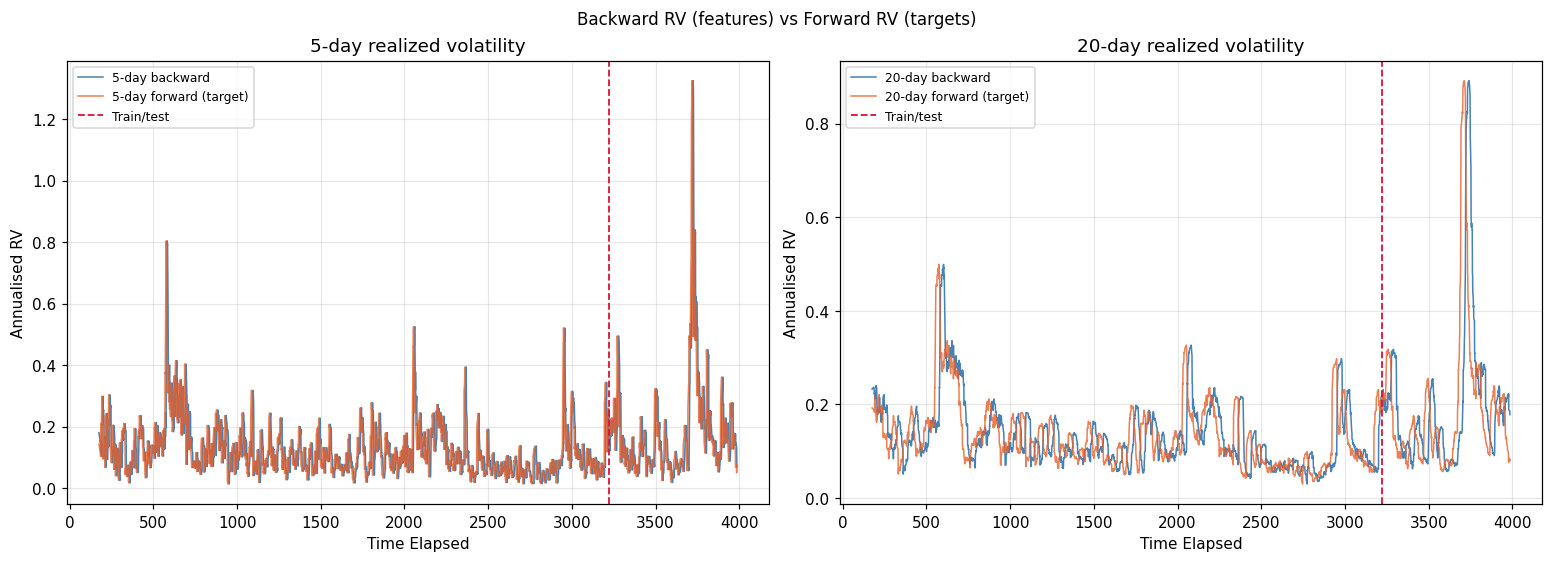

In [12]:
# Backward vs forward realized volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Backward RV (features) vs Forward RV (targets)', fontsize=11)

for ax, bw, fw, label in zip(
    axes,
    ['RV5',  'RV20'],
    ['target_RV5', 'target_RV20'],
    ['5-day', '20-day'],
):
    ax.plot(te, daily_clean[bw],  lw=1.0, color='steelblue', label=f'{label} backward')
    ax.plot(te, daily_clean[fw],  lw=1.0, color='#E8602B', alpha=0.8, label=f'{label} forward (target)')
    ax.axvline(daily_clean.loc[daily_clean['sample']=='test','time_elapsed'].min(),
               color='crimson', lw=1.2, ls='--', label='Train/test')
    ax.set_xlabel('Time Elapsed')
    ax.set_ylabel('Annualised RV')
    ax.set_title(f'{label} realized volatility')
    ax.legend(fontsize=8)

plt.show()

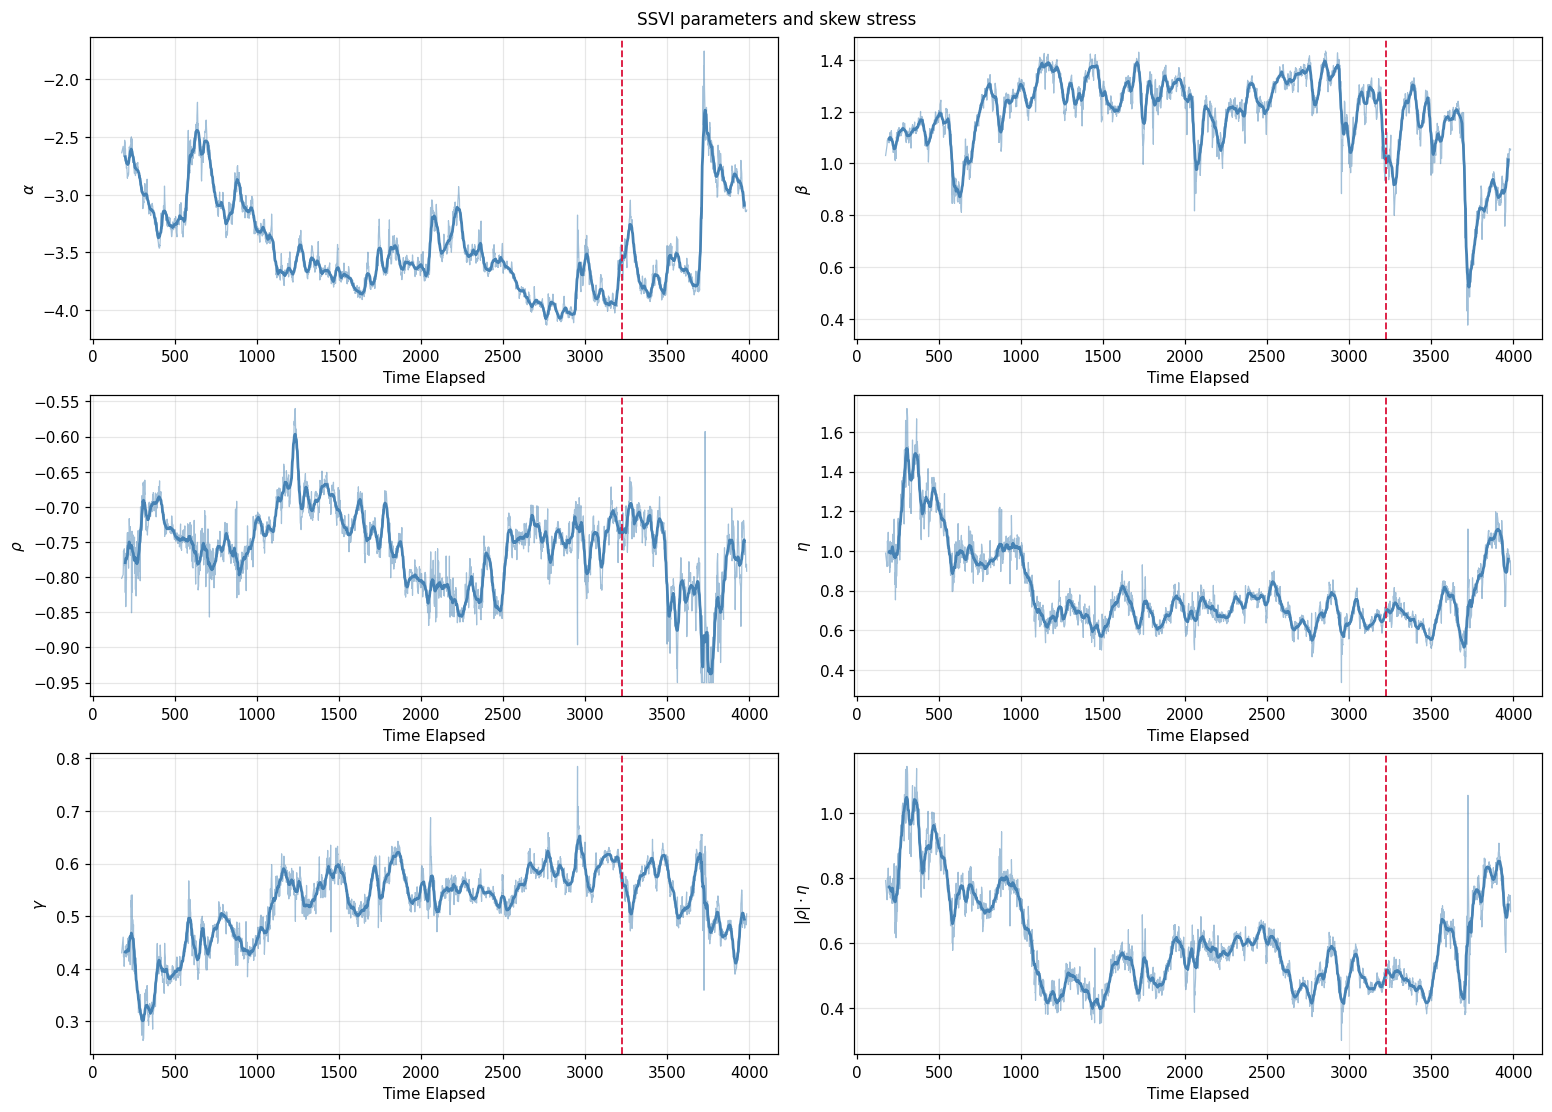

In [13]:
# SSVI parameter time series
params  = ['alpha', 'beta', 'rho', 'eta', 'gamma', 'skew_stress']
ylabels = [r'$\alpha$', r'$\beta$', r'$\rho$',
            r'$\eta$', r'$\gamma$', r'$|\rho| \cdot \eta$']

fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle('SSVI parameters and skew stress', fontsize=11)
split_te = daily_clean.loc[daily_clean['sample']=='test','time_elapsed'].min()

for ax, col, lab in zip(axes.flat, params, ylabels):
    ax.plot(te, daily_clean[col], lw=0.8, color='steelblue', alpha=0.5)
    ax.plot(te, daily_clean[col].rolling(20, center=True).mean(), lw=1.8, color='steelblue')
    ax.axvline(split_te, color='crimson', lw=1.2, ls='--')
    ax.set_ylabel(lab)
    ax.set_xlabel('Time Elapsed')

plt.show()

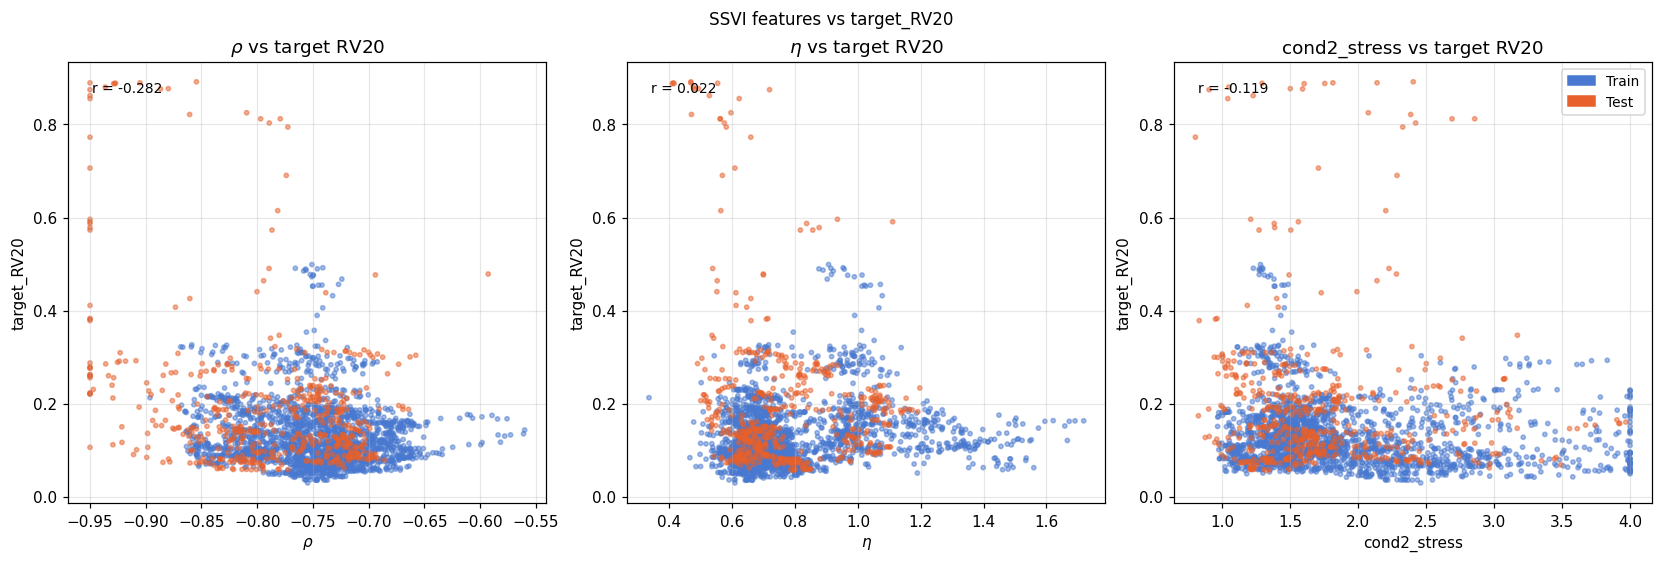

In [14]:
# SSVI parameters vs future RV20 (scatter)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle('SSVI features vs target_RV20', fontsize=11)

for ax, xvar, xlabel in zip(
    axes,
    ['rho',       'eta',        'cond2_stress'],
    [r'$\rho$',  r'$\eta$',   'cond2_stress'],
):
    colors = daily_clean['sample'].map({'train': '#4878CF', 'test': '#E8602B'})
    ax.scatter(daily_clean[xvar], daily_clean['target_RV20'],
               s=8, alpha=0.5, c=colors)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('target_RV20')
    ax.set_title(f'{xlabel} vs target RV20')
    r = daily_clean[[xvar,'target_RV20']].corr().iloc[0,1]
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes, fontsize=9)

# Legend
from matplotlib.patches import Patch
axes[-1].legend(handles=[
    Patch(color='#4878CF', label='Train'),
    Patch(color='#E8602B', label='Test'),
], fontsize=9, loc='upper right')

plt.show()

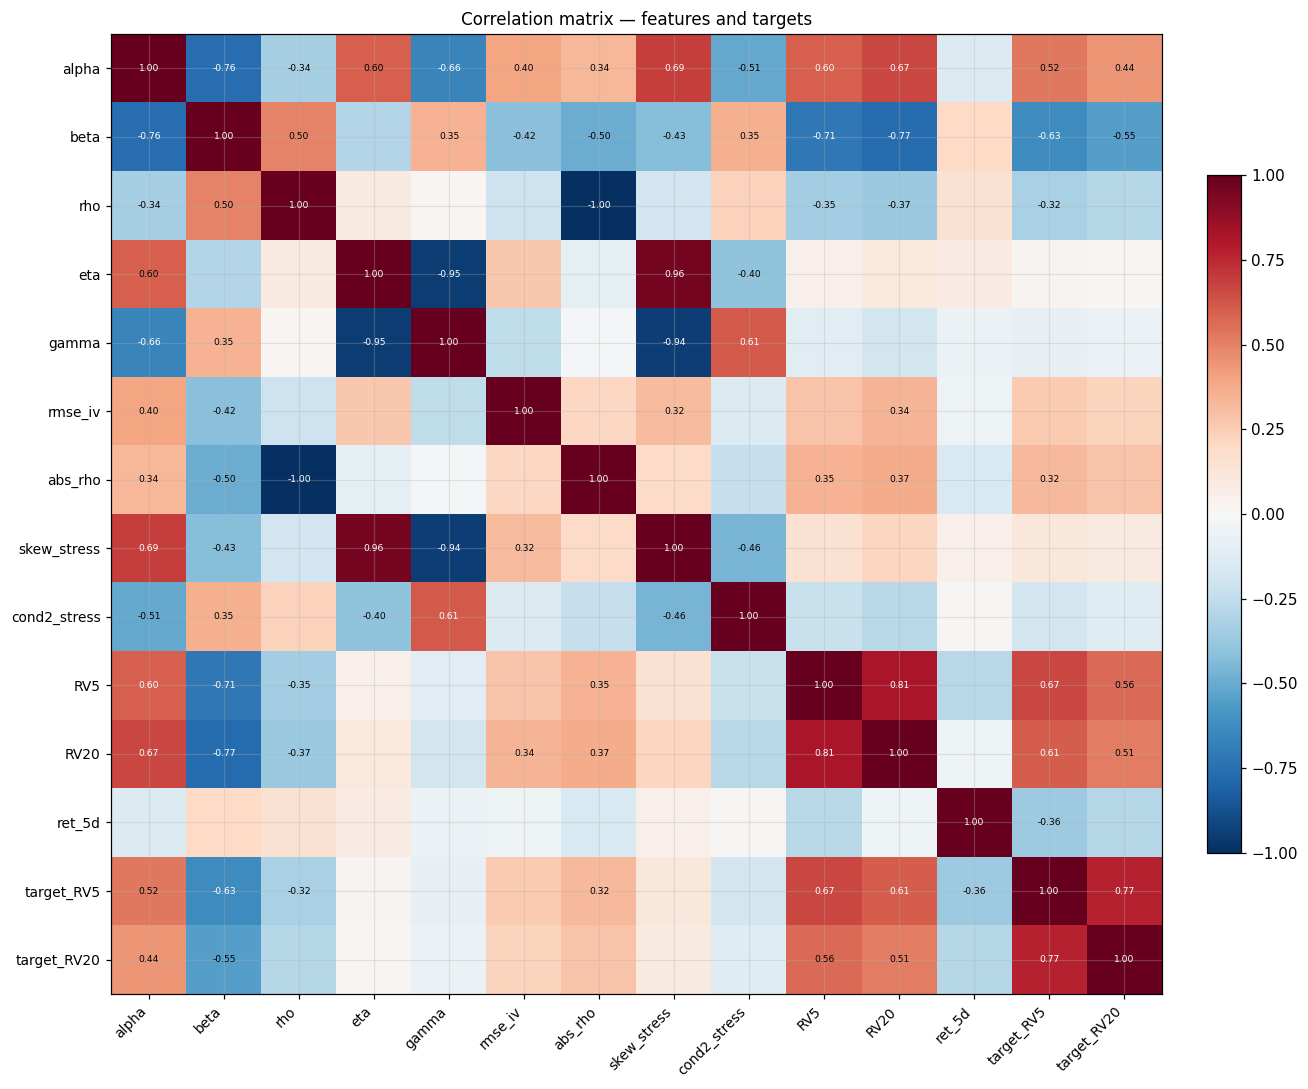

In [15]:
# Correlation heatmap — features vs targets
heatmap_cols = [
    'alpha','beta','rho','eta','gamma','rmse_iv',
    'abs_rho','skew_stress','cond2_stress',
    'RV5','RV20','ret_5d',
    'target_RV5','target_RV20',
]
corr_mat = daily_clean[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(len(heatmap_cols)))
ax.set_yticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(heatmap_cols, fontsize=9)

# Annotate cells
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        v = corr_mat.values[i, j]
        if abs(v) > 0.3:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(v) > 0.6 else 'black')

ax.set_title('Correlation matrix — features and targets', fontsize=11)
plt.tight_layout()
plt.show()

## J. Why this dataset design works

### Target: future realized volatility

We predict $RV_t^{h} = \sqrt{252 \cdot \frac{1}{h}\sum_{i=1}^{h} r_{t+i}^2}$
(annualised, over the next $h$ trading days).

This is a **genuine out-of-sample quantity** at time $t$:
the model must learn a true economic relationship between today's market state and
tomorrow's volatility regime.

**Why not predict ATM IV?** ATM IV is an output of the same SSVI calibration as the features.
Using it as a target would create an autoreferential problem — the model would essentially
be recovering the SSVI surface from itself, not learning anything about future risk.
Future realized volatility is economically independent of today's implied surface.

### Why SSVI parameters contain forward-looking information

The implied volatility surface encodes the market's *risk-neutral expectation* of future
variance. In the risk-neutral measure, $\mathbb{E}^Q[\sigma_{RV}^2] \approx \sigma_{ATM}^2$
(the variance risk premium is typically positive but predictable). Specifically:

- **$\alpha$** (level) tracks the aggregate variance expectation
- **$\rho$** (skew) reflects crash-fear and leverage-effect intensity
- **$\eta$, $\gamma$** (smile curvature) capture tail-risk pricing beyond ATM
- **cond2_stress** = $\theta\phi^2(1+|\rho|)$ is a non-parametric measure of how
  tightly the surface is priced relative to the no-arbitrage boundary — high values
  signal stress regimes

Academic evidence (Carr & Wu 2009, Bollerslev et al. 2014) confirms that the
*slope* and *curvature* of the implied surface predict future realized variance
beyond what backward-looking RV measures alone can explain.

### No-look-ahead guarantee

| Quantity | Uses data from... | Safe? |
|----------|-------------------|-------|
| `RV5`, `RV20` (backward) | $t-w, \ldots, t$ | ✓ |
| `alpha`, `rho`, ... | calibrated at $t$ | ✓ |
| `alpha_lag1` | $t-1$ | ✓ |
| `target_RV5` | $t+1, \ldots, t+5$ | ✓ (target only) |

Rolling windows and lags are always backward-looking.
Forward-shifted quantities appear **only** in the target columns and are never used
as features.

### Temporal train/test split

A random split would contaminate the test set: if a test observation sits between
two training observations in calendar time, its lagged features already exist in
training data, leaking future information through autocorrelation.

A **temporal split** (train = first 80%, test = last 20%) preserves causality:
the model is trained on the past and evaluated on the future, mimicking real
deployment conditions.

## K. Final dataset summary

In [16]:
print('=== Forecasting dataset ===')
print(f'  Shape              : {daily_clean.shape}')
print(f'  Train observations : {(daily_clean["sample"]=="train").sum()}')
print(f'  Test  observations : {(daily_clean["sample"]=="test").sum()}')
print(f'  Feature columns    : {len(FEATURE_COLS)}')
print(f'  Target columns     : {TARGET_COLS}')
print(f'  Saved to           : {OUT_PATH}')
print()
print('Columns in output file:')
print([c for c in daily_clean.columns])

=== Forecasting dataset ===
  Shape              : (2621, 61)
  Train observations : 2096
  Test  observations : 525
  Feature columns    : 50
  Target columns     : ['target_RV5', 'target_RV20']
  Saved to           : C:\Users\alpor\OneDrive\Desktop\politecnico\MAGISTRALE II\Insurance & Econometrics\ECONOMETRICS\PROGETTO\Notebook_newdata\output\ssvi_forecasting_dataset.csv

Columns in output file:
['time_elapsed', 'sp500', 'alpha', 'beta', 'rho', 'eta', 'gamma', 'rmse_iv', 'n_obs', 'max_cond1', 'max_cond2', 'butterfly_ok', 'calendar_ok', 'no_arbitrage', 'log_return', 'abs_return', 'squared_return', 'RV5', 'RV10', 'RV20', 'ret_5d', 'ret_20d', 'abs_rho', 'eta_gamma_interaction', 'skew_stress', 'cond2_stress', 'alpha_lag1', 'alpha_lag2', 'alpha_lag5', 'beta_lag1', 'beta_lag2', 'beta_lag5', 'rho_lag1', 'rho_lag2', 'rho_lag5', 'eta_lag1', 'eta_lag2', 'eta_lag5', 'gamma_lag1', 'gamma_lag2', 'gamma_lag5', 'rmse_iv_lag1', 'rmse_iv_lag2', 'rmse_iv_lag5', 'max_cond2_lag1', 'max_cond2_lag2', 'ma